# Project 2: Has the Structure of Risk Changed Since COVID-19?

**Group:** Danny Al Fallouji, Selim Grar, Diona Avdija. EMiF, Prof. F. Ielpo.

Reproducible engine for the report. It runs the analysis and writes every table and figure to
`results/`. All interpretation is in `report/report_v3.pdf`. Runs top-to-bottom from `data/Data.xlsx`
on the `emif-project2` kernel. Layout: diagnostics, then Block A (marginals), Block B (dependence),
Block C (dynamics), synthesis.

## 1. Setup

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, scipy.stats as scstats
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import breaks_cusumolsresid, acorr_ljungbox
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from arch import arch_model
from scipy.optimize import minimize
from scipy.stats import genpareto, chi2 as chi2_dist

warnings.filterwarnings('ignore')        # silences known arch/statsmodels chatter only
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')

COVID_BREAK_DATE    = pd.Timestamp('2020-03-01')
RECENT_PRE_START    = pd.Timestamp('2015-01-01')   # recent-calm benchmark
ROLLING_WINDOW_DAYS = 60
HAC_LAGS            = 6
GARCH_SCALE         = 100
GPD_PCTILE          = 0.95                          # principled EVT threshold
N_BOOT              = 2000
BLOCK_LEN           = 6                             # ~ half the 60-day window, in months
SEED                = 42

## 2. Data loading

In [2]:
ProjectRoot = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'Data.xlsx').exists())
RESULTS_DIR = ProjectRoot / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

RawDataFrame = pd.read_excel(ProjectRoot / 'data' / 'Data.xlsx', sheet_name='Feuil1')
RawDataFrame = RawDataFrame.rename(columns={'Unnamed: 0': 'Date'})
RawDataFrame['Date'] = pd.to_datetime(RawDataFrame['Date'])
RawDataFrame = RawDataFrame.sort_values('Date').set_index('Date')

COLUMN_RENAME = {'S&P500':'SP500', 'Eurostoxx 50':'EuroStoxx50', 'Hang Seng':'HangSeng',
                 'MSCI EM':'MSCIEm', 'SMI':'SMI', 'US T 10-year Yield':'US10Y',
                 'German Gov 10-year yield':'DE10Y', 'Oil futures':'Oil', 'Gold':'Gold',
                 'EURUSD':'EURUSD', 'USDJPY':'USDJPY', 'US IG Bonds':'USIG',
                 'US HY Bonds':'USHY', 'USDCHF':'USDCHF'}
PriceDataFrame = RawDataFrame.rename(columns=COLUMN_RENAME).ffill(limit=2)
print('Raw data:', PriceDataFrame.shape, '| from', PriceDataFrame.index.min().date(),
      'to', PriceDataFrame.index.max().date())
PriceDataFrame.tail(3)

Raw data: (9601, 14) | from 1989-12-31 to 2026-04-24


,SP500,EuroStoxx50,HangSeng,MSCIEm,SMI,US10Y,DE10Y,Oil,Gold,EURUSD,USDJPY,USIG,USHY,USDCHF
Date,,,,,,,,,,,,,,
2026-04-22,7137.8999,5906.2202,26163.2402,1607.0699,13067.6299,4.3025,3.0084,92.9600,4739.8999,1.1705,159.4800,3613.8870,2696.9160,0.7847
2026-04-23,7108.3999,5894.7300,25915.1992,1599.3101,13248.0596,4.3244,3.0090,95.8500,4694.1401,1.1683,159.7100,3608.3889,2694.0430,0.7864
2026-04-24,7165.0801,5883.4800,25978.0703,1610.0000,13169.7002,4.3007,2.9937,94.4000,4709.5000,1.1722,159.3800,3612.0129,2695.6079,0.7850


## 3. Daily transformations

In [3]:
PRICE_SERIES  = ['SP500','EuroStoxx50','HangSeng','MSCIEm','SMI',
                 'Oil','Gold','EURUSD','USDJPY','USDCHF','USIG','USHY']
YIELD_SERIES  = ['US10Y','DE10Y']
ALL_SERIES    = PRICE_SERIES + YIELD_SERIES
EQUITY_SERIES = ['SP500','EuroStoxx50','HangSeng','MSCIEm','SMI']

# Prices -> log-returns; yields are rates, not prices -> first differences (a log-return on a yield
# has no economic meaning). This is the standard course treatment.
DailyLogReturns = np.log(PriceDataFrame[PRICE_SERIES]).diff()
DailyYieldDiffs = PriceDataFrame[YIELD_SERIES].diff()
DailyReturnsAll = pd.concat([DailyLogReturns, DailyYieldDiffs], axis=1).dropna(how='all')

# Equal-weight equity composite used throughout the paper (one series to summarise "the market").
EquityComposite          = DailyLogReturns[EQUITY_SERIES].mean(axis=1)
DailyCreditSpread        = DailyLogReturns['USHY'] - DailyLogReturns['USIG']   # CRS
DailyTransatlanticSpread = PriceDataFrame['US10Y'] - PriceDataFrame['DE10Y']   # TAS (in level)
print(f'Daily returns: {DailyReturnsAll.shape[0]} obs, {DailyReturnsAll.shape[1]} series')

Daily returns: 9600 obs, 14 series


## 4. Preliminary diagnostics  (Report: Table 1; Section 4 intro)

In [4]:
# Jarque-Bera: does any series look Gaussian? (We expect a clean "no" everywhere.)
JBRows = []
for col in ALL_SERIES:
    r = DailyReturnsAll[col].dropna()
    jb_stat, jb_p = scstats.jarque_bera(r)
    JBRows.append({'series': col,
                   'skewness': float(scstats.skew(r)),
                   'excess_kurtosis': float(scstats.kurtosis(r)),   # scipy default = excess (K-3)
                   'JB_stat': jb_stat, 'JB_pvalue': jb_p,
                   'reject_normality': 'yes' if jb_p < 0.05 else 'no'})
JBTable = pd.DataFrame(JBRows).set_index('series')
JBTable.to_csv(RESULTS_DIR / 'table1_normality_tests.csv')
print('Normality rejected for', (JBTable.reject_normality == "yes").sum(), 'of', len(JBTable), 'series.')
JBTable

Normality rejected for 14 of 14 series.


,skewness,excess_kurtosis,JB_stat,JB_pvalue,reject_normality
series,,,,,
SP500,-0.3599,11.5522,53549.6147,0.0000,yes
EuroStoxx50,-0.2544,6.8689,18958.4778,0.0000,yes
HangSeng,-0.1578,9.6400,36944.5830,0.0000,yes
MSCIEm,-0.5386,7.6471,23852.9100,0.0000,yes
SMI,-0.3788,7.8497,24674.3465,0.0000,yes
Oil,-0.5425,21.4800,182308.7885,0.0000,yes
Gold,-0.2954,8.0987,26342.1229,0.0000,yes
EURUSD,0.0078,2.1423,1835.1018,0.0000,yes
USDJPY,-0.3843,5.5710,12649.3260,0.0000,yes


In [5]:
# Ljung-Box at lag 10: returns (mean) and squared returns (ARCH effects).
LBRows = []
for col in ALL_SERIES:
    r = DailyReturnsAll[col].dropna()
    p_ret = float(acorr_ljungbox(r,    lags=[10], return_df=True)['lb_pvalue'].iloc[-1])
    p_sq  = float(acorr_ljungbox(r**2, lags=[10], return_df=True)['lb_pvalue'].iloc[-1])
    LBRows.append({'series': col, 'LB_returns_p10': p_ret, 'LB_squared_p10': p_sq,
                   'ARCH_effects': 'yes' if p_sq < 0.05 else 'no'})
LBTable = pd.DataFrame(LBRows).set_index('series')
print('ARCH effects detected in', (LBTable.ARCH_effects == "yes").sum(), 'of', len(LBTable), 'series.')
LBTable

ARCH effects detected in 13 of 14 series.


,LB_returns_p10,LB_squared_p10,ARCH_effects
series,,,
SP500,0.0000,0.0000,yes
EuroStoxx50,0.0000,0.0000,yes
HangSeng,0.0735,0.0000,yes
MSCIEm,0.0000,0.0000,yes
SMI,0.0000,0.0000,yes
Oil,0.0000,0.0000,yes
Gold,0.0004,0.0000,yes
EURUSD,0.1757,0.0000,yes
USDJPY,0.0733,0.0000,yes


## 5. Monthly risk measures

In [6]:
# Square-root of the sum of squared daily returns within each month (Andersen-Bollerslev).
def monthly_realized_vol(daily_series):
    return np.sqrt((daily_series ** 2).resample('BME').sum())

MonthlyEquityRealizedVol = monthly_realized_vol(EquityComposite)
MonthlyEquityRealizedVol.name = 'sigma_eq'

MonthlyControls = pd.DataFrame({
    'sigma_oil':    monthly_realized_vol(DailyLogReturns['Oil']),
    'sigma_gold':   monthly_realized_vol(DailyLogReturns['Gold']),
    'sigma_em':     monthly_realized_vol(DailyLogReturns['MSCIEm']),
    'sigma_hs':     monthly_realized_vol(DailyLogReturns['HangSeng']),
    'sigma_usdjpy': monthly_realized_vol(DailyLogReturns['USDJPY']),
    'sigma_eurusd': monthly_realized_vol(DailyLogReturns['EURUSD']),
    'abs_usdchf':   DailyLogReturns['USDCHF'].abs().resample('BME').mean(),
    'CRS':          DailyCreditSpread.resample('BME').sum(),
    'TAS':          DailyTransatlanticSpread.resample('BME').last(),
    'Delta_US10Y':  PriceDataFrame['US10Y'].resample('BME').last().diff(),
})

In [7]:
# At each month-end, take the trailing `window_days` daily returns and compute:
#   rho_bar = mean pairwise correlation, lambda_1 = PC1 variance share,
#   K_eff   = exp(entropy of eigenvalue shares) = effective number of risk factors.
def compute_rolling_measures(daily_ret_frame, window_days):
    MonthEnds = pd.date_range(daily_ret_frame.index.min(), daily_ret_frame.index.max(), freq='BME')
    records = []
    for me in MonthEnds:
        avail = daily_ret_frame.index[daily_ret_frame.index <= me]
        if len(avail) == 0:
            continue
        pos = daily_ret_frame.index.get_loc(avail[-1])
        if pos + 1 < window_days:
            continue
        Window = daily_ret_frame.iloc[pos + 1 - window_days : pos + 1].dropna()
        if len(Window) < int(0.8 * window_days):
            continue
        C = Window.corr().values
        rho_bar = C[np.triu_indices(C.shape[0], k=1)].mean()
        # z-score within the window so PCA reflects correlations, not raw variances
        Std = (Window - Window.mean()) / Window.std(ddof=1)
        eig = np.sort(np.linalg.eigvalsh(np.cov(Std.values, rowvar=False)))[::-1]
        eig = np.maximum(eig, 1e-10)
        shares = eig / eig.sum()
        lambda_1 = shares[0]
        k_eff    = np.exp(-np.sum(shares * np.log(np.maximum(shares, 1e-12))))
        records.append({'Date': me, 'rho_bar': rho_bar, 'lambda_1': lambda_1, 'K_eff': k_eff})
    return pd.DataFrame.from_records(records).set_index('Date')

MonthlyRollingMeasures = compute_rolling_measures(DailyReturnsAll, ROLLING_WINDOW_DAYS)
print(f'Rolling measures: {MonthlyRollingMeasures.shape[0]} months')

Rolling measures: 421 months


In [8]:
# Sub-block correlations (equity vs each asset class) -- used in the discussion, not the regressions.
BOND_SERIES, COMMO_SERIES, FX_SERIES = ['US10Y','DE10Y'], ['Oil','Gold'], ['EURUSD','USDJPY','USDCHF']

def compute_subblock_rho(df, series_a, series_b, window_days):
    MonthEnds = pd.date_range(df.index.min(), df.index.max(), freq='BME')
    cols = list(dict.fromkeys(series_a + series_b))
    records = []
    for me in MonthEnds:
        avail = df.index[df.index <= me]
        if len(avail) == 0:
            continue
        pos = df.index.get_loc(avail[-1])
        if pos + 1 < window_days:
            continue
        W = df.iloc[pos + 1 - window_days : pos + 1][cols].dropna()
        if len(W) < int(0.8 * window_days):
            continue
        C = W.corr()
        cross = [C.loc[a, b] for a in series_a for b in series_b if a != b]
        records.append({'Date': me, 'rho': float(np.mean(cross))})
    return pd.DataFrame.from_records(records).set_index('Date')['rho']

MonthlyRhoEquity  = compute_subblock_rho(DailyReturnsAll, EQUITY_SERIES, EQUITY_SERIES, ROLLING_WINDOW_DAYS)
MonthlyRhoEqBond  = compute_subblock_rho(DailyReturnsAll, EQUITY_SERIES, BOND_SERIES,   ROLLING_WINDOW_DAYS)
MonthlyRhoEqCommo = compute_subblock_rho(DailyReturnsAll, EQUITY_SERIES, COMMO_SERIES,  ROLLING_WINDOW_DAYS)
MonthlyRhoEqFX    = compute_subblock_rho(DailyReturnsAll, EQUITY_SERIES, FX_SERIES,     ROLLING_WINDOW_DAYS)
print('Sub-block correlations computed.')

Sub-block correlations computed.


## 6. Monthly panel

In [9]:
MonthlyDataFrame = pd.concat([MonthlyRollingMeasures, MonthlyEquityRealizedVol, MonthlyControls], axis=1)
MonthlyDataFrame = MonthlyDataFrame.dropna(subset=['rho_bar', 'sigma_eq'])
MonthlyDataFrame['D_post'] = (MonthlyDataFrame.index >= COVID_BREAK_DATE).astype(int)

LAG_COLS = ['sigma_eq','sigma_oil','sigma_gold','sigma_em','sigma_hs',
            'sigma_usdjpy','sigma_eurusd','abs_usdchf','CRS','TAS','Delta_US10Y',
            'rho_bar','lambda_1','K_eff']
for c in LAG_COLS:
    MonthlyDataFrame[c + '_lag1'] = MonthlyDataFrame[c].shift(1)   # regressors lagged: no look-ahead

MonthlyDataFrame['sigma_eq_lag1_x_D_post'] = MonthlyDataFrame['sigma_eq_lag1'] * MonthlyDataFrame['D_post']
D_stress_thr = MonthlyDataFrame['sigma_eq_lag1'].quantile(0.75)
MonthlyDataFrame['D_stress'] = (MonthlyDataFrame['sigma_eq_lag1'] > D_stress_thr).astype(int)
MonthlyDataFrame['sigma_eq_lag1_x_D_stress'] = MonthlyDataFrame['sigma_eq_lag1'] * MonthlyDataFrame['D_stress']

MonthlyDF = MonthlyDataFrame.dropna(subset=['sigma_eq_lag1']).copy()
print(f'{MonthlyDF.shape[0]} months ({(MonthlyDF.D_post==0).sum()} pre, {(MonthlyDF.D_post==1).sum()} post)')

420 months (347 pre, 73 post)


## 7. Stationarity: ADF + KPSS  (Report: Appendix A)

In [10]:
ADFRows, KPSSRows = [], []
for col in ['sigma_eq', 'rho_bar', 'lambda_1', 'K_eff']:
    s = MonthlyDataFrame[col].dropna()
    adf_stat, adf_p, *_ , crit, _ = adfuller(s, autolag='AIC')
    ADFRows.append({'series': col, 'ADF_stat': adf_stat, 'ADF_p': adf_p,
                    'stationary_ADF': 'yes' if adf_p < 0.05 else 'no'})
    ks, kp, _, _ = kpss(s, regression='c', nlags='auto')   # KPSS p is discrete in [0.01, 0.10]
    KPSSRows.append({'series': col, 'KPSS_stat': ks, 'KPSS_p': round(kp, 4),
                     'stationary_KPSS': 'yes' if kp > 0.05 else 'no'})
print('=== ADF (H0: unit root; p<0.05 stationary) ===');  print(pd.DataFrame(ADFRows).set_index('series'))
print('\n=== KPSS (H0: stationary; p>0.05 stationary) ===')
print(pd.DataFrame(KPSSRows).set_index('series'))

=== ADF (H0: unit root; p<0.05 stationary) ===
          ADF_stat  ADF_p stationary_ADF
series                                  
sigma_eq   -5.6623 0.0000            yes
rho_bar    -2.4590 0.1258             no
lambda_1   -4.1233 0.0009            yes
K_eff      -2.9908 0.0358            yes

=== KPSS (H0: stationary; p>0.05 stationary) ===
          KPSS_stat  KPSS_p stationary_KPSS
series                                     
sigma_eq     0.1656  0.1000             yes
rho_bar      1.6532  0.0100              no
lambda_1     1.3233  0.0100              no
K_eff        1.9255  0.0100              no


## 8. Inference helper: stationary block bootstrap  (Report: Section 3)

In [11]:
# Two-sided block-bootstrap p-value for the (post - pre) difference in `stat` ('mean' or 'var').
# Pre = months before break_date, Post = months from break_date onward. Contiguous blocks of length
# `block_len` are drawn with wrap-around from the pooled sample (null: same dependent process).
def block_boot_pvalue(series, break_date, stat='mean', n_boot=N_BOOT,
                      block_len=BLOCK_LEN, seed=SEED, start=None):
    rng = np.random.default_rng(seed)
    s = series.dropna()
    if start is not None:
        s = s[s.index >= start]
    pre  = s[s.index <  break_date].values
    post = s[s.index >= break_date].values
    f = (lambda v: v.mean()) if stat == 'mean' else (lambda v: v.var(ddof=1))
    observed = f(post) - f(pre)
    pooled, T = s.values, len(s)
    n_pre, n_post = len(pre), len(post)
    def draw(n):
        out = []
        while len(out) < n:
            st = rng.integers(0, T)
            out.extend(np.take(pooled, range(st, st + block_len), mode='wrap'))
        return np.array(out[:n])
    count = sum(abs(f(draw(n_post)) - f(draw(n_pre))) >= abs(observed) for _ in range(n_boot))
    return observed, (count + 1) / (n_boot + 1)

# quick self-check
_d, _p = block_boot_pvalue(MonthlyDataFrame['sigma_eq'], COVID_BREAK_DATE, 'mean')
print(f'self-check sigma_eq mean diff={_d:+.5f}, block-boot p={_p:.3f}')

self-check sigma_eq mean diff=-0.00017, block-boot p=0.971


## 9. Breakpoint validation: Chow + CUSUM  (Report: Section 3, Data)

In [12]:
YBase = MonthlyDF['rho_bar']
XBase = sm.add_constant(MonthlyDF[['sigma_eq_lag1']])

def chow_test(y, X, break_date):
    n, k = len(y), X.shape[1]
    pre, post = y.index < break_date, y.index >= break_date
    rss_full  = (sm.OLS(y, X).fit().resid ** 2).sum()
    rss_split = ((sm.OLS(y[pre],  X[pre]).fit().resid  ** 2).sum() +
                 (sm.OLS(y[post], X[post]).fit().resid ** 2).sum())
    F = ((rss_full - rss_split) / k) / (rss_split / (n - 2 * k))
    return F, 1 - scstats.f.cdf(F, k, n - 2 * k)

F_chow, p_chow = chow_test(YBase, XBase, COVID_BREAK_DATE)
cusum_stat, p_cusum, _ = breaks_cusumolsresid(sm.OLS(YBase, XBase).fit().resid, ddof=XBase.shape[1])
print(f'Chow  : F = {F_chow:.3f}, p = {p_chow:.3f}  '
      f'({"break" if p_chow < 0.05 else "no discrete jump at March 2020"})')
print(f'CUSUM : stat = {cusum_stat:.3f}, p = {p_cusum:.4f}  '
      f'({"parameter instability" if p_cusum < 0.05 else "stable"})')

Chow  : F = 0.784, p = 0.457  (no discrete jump at March 2020)
CUSUM : stat = 7.357, p = 0.0000  (parameter instability)


# Block A. Marginal risk

### A1. Realised volatility level  (Report: Table 2, Figure 1)

In [13]:
# Pre/post comparison of the four monthly risk measures, with HONEST inference:
# block-bootstrap p-values for both the mean and the variance, against TWO benchmarks
# (full pre-COVID history, and recent 2015-2020 calm).
DescRows = []
for s in ['sigma_eq', 'rho_bar', 'lambda_1', 'K_eff']:
    series = MonthlyDF[s]
    pre  = series[series.index <  COVID_BREAK_DATE]
    post = series[series.index >= COVID_BREAK_DATE]
    recent = series[(series.index >= RECENT_PRE_START) & (series.index < COVID_BREAK_DATE)]
    _, p_mean_full   = block_boot_pvalue(series, COVID_BREAK_DATE, 'mean')
    _, p_var_full    = block_boot_pvalue(series, COVID_BREAK_DATE, 'var')
    _, p_mean_recent = block_boot_pvalue(series, COVID_BREAK_DATE, 'mean', start=RECENT_PRE_START)
    DescRows.append({'series': s, 'pre_mean': pre.mean(), 'recent_pre_mean': recent.mean(),
                     'post_mean': post.mean(), 'pre_std': pre.std(ddof=1), 'post_std': post.std(ddof=1),
                     'p_mean_full_boot': p_mean_full, 'p_mean_recent_boot': p_mean_recent,
                     'p_var_full_boot': p_var_full})
DescTable = pd.DataFrame(DescRows).set_index('series')
DescTable.to_csv(RESULTS_DIR / 'table2_descriptive_stats.csv')
print('Block-bootstrap p-values (vs naive i.i.d. tests, which would read ~0.000 for K_eff):')
DescTable

Block-bootstrap p-values (vs naive i.i.d. tests, which would read ~0.000 for K_eff):


,pre_mean,recent_pre_mean,post_mean,pre_std,post_std,p_mean_full_boot,p_mean_recent_boot,p_var_full_boot
series,,,,,,,,
sigma_eq,0.0378,0.0324,0.0376,0.0216,0.0212,0.9660,0.2714,0.9595
rho_bar,0.0813,0.1184,0.0900,0.0694,0.0561,0.6387,0.1119,0.1769
lambda_1,0.3351,0.3675,0.3399,0.0696,0.0475,0.7616,0.1079,0.0460
K_eff,7.6917,7.0408,7.2496,1.1577,0.6136,0.1459,0.3338,0.0190


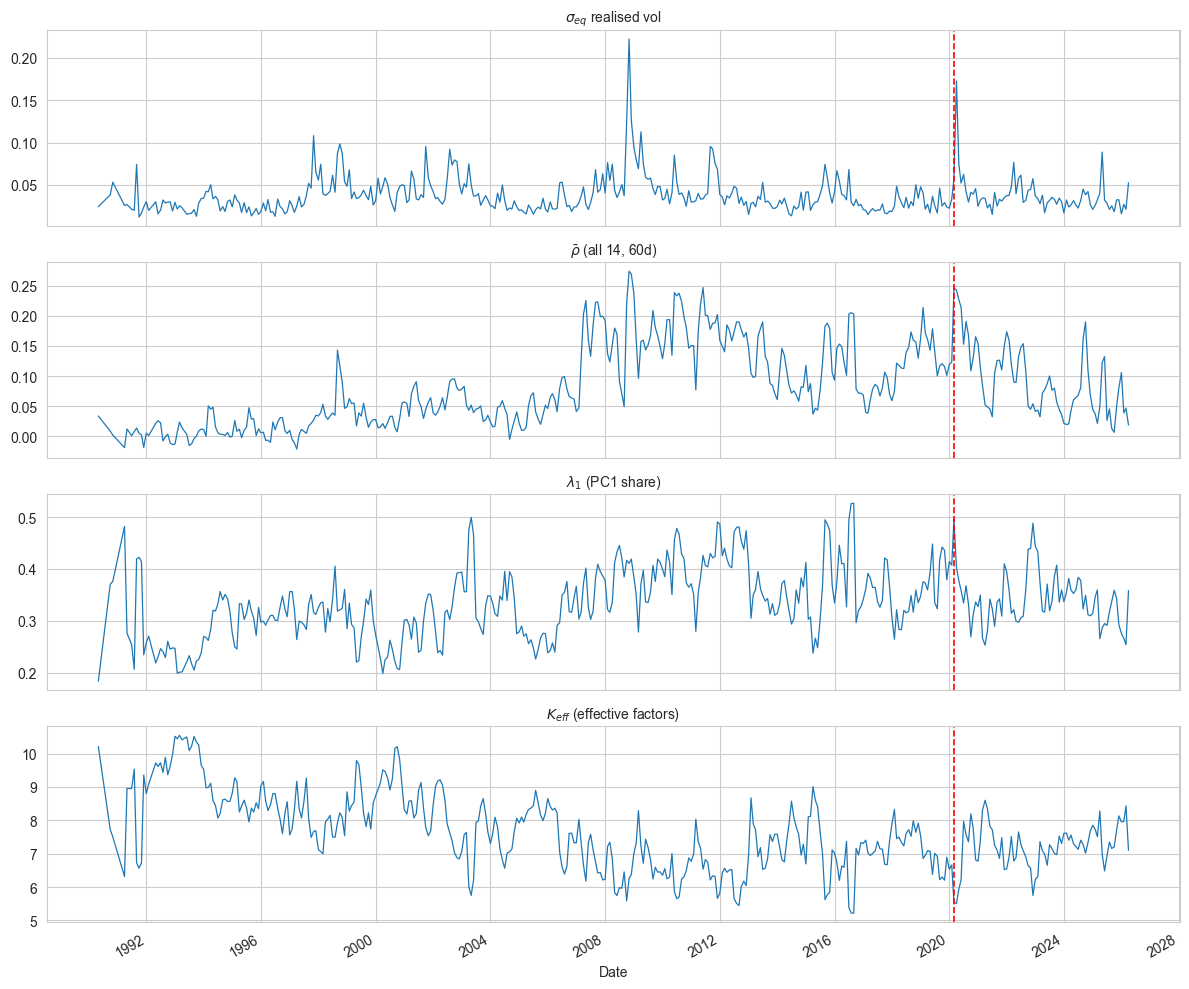

In [14]:
# fig1: the four monthly risk measures with the COVID line.
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
labels = [r'$\sigma_{eq}$ realised vol', r'$\bar{\rho}$ (all 14, 60d)',
          r'$\lambda_1$ (PC1 share)', r'$K_{eff}$ (effective factors)']
for ax, col, lbl in zip(axes, ['sigma_eq','rho_bar','lambda_1','K_eff'], labels):
    MonthlyDF[col].plot(ax=ax, lw=0.9)
    ax.axvline(COVID_BREAK_DATE, color='red', ls='--', lw=1.2)
    ax.set_title(lbl, fontsize=10)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig1_risk_measures_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

### A2. Volatility dynamics: GARCH and GJR  (Report: Tables 3-4, Figure 3)

In [15]:
# We run GARCH on the EQUITY COMPOSITE (the series the rest of the paper uses), not on SP500 alone,
# so the volatility-dynamics result is consistent with the dependence and regression blocks.
CompReturns = EquityComposite.dropna() * GARCH_SCALE
CompPre  = CompReturns[CompReturns.index <  COVID_BREAK_DATE]
CompPost = CompReturns[CompReturns.index >= COVID_BREAK_DATE]

def fit_garch(series, o=0):
    return arch_model(series, vol='Garch', p=1, o=o, q=1, dist='t', mean='Constant').fit(disp='off')

GarchFull, GarchPre, GarchPost = fit_garch(CompReturns), fit_garch(CompPre), fit_garch(CompPost)

def garch_row(label, res):
    a, b = res.params['alpha[1]'], res.params['beta[1]']
    return {'period': label, 'omega': res.params['omega'], 'alpha': a, 'beta': b,
            'alpha+beta': a + b, 'nu': res.params['nu'], 'loglik': res.loglikelihood,
            'converged': res.convergence_flag == 0}
GarchSummary = pd.DataFrame([garch_row('Full', GarchFull), garch_row('Pre-COVID', GarchPre),
                             garch_row('Post-COVID', GarchPost)]).set_index('period')
GarchSummary.to_csv(RESULTS_DIR / 'table3_garch_estimates.csv')

LR_garch = -2 * (GarchFull.loglikelihood - GarchPre.loglikelihood - GarchPost.loglikelihood)
p_lr_garch = 1 - chi2_dist.cdf(LR_garch, df=4)
print(GarchSummary)
print(f'\nLR break test (H0: same params pre/post): LR = {LR_garch:.2f}, p = {p_lr_garch:.4f}  (chi2, df=4)')

# Residual diagnostics on the full-sample fit
z = (GarchFull.resid / GarchFull.conditional_volatility).dropna()
print(f'LB(z)   p = {acorr_ljungbox(z,    lags=[10], return_df=True).lb_pvalue.iloc[-1]:.3f}  (mean)')
print(f'LB(z^2) p = {acorr_ljungbox(z**2, lags=[10], return_df=True).lb_pvalue.iloc[-1]:.3f}  (variance: >0.05 = clean)')

            omega  alpha   beta  alpha+beta     nu      loglik  converged
period                                                                   
Full       0.0120 0.1122 0.8778      0.9900 6.0073 -10777.2978       True
Pre-COVID  0.0097 0.1068 0.8862      0.9929 6.1610  -8914.6413       True
Post-COVID 0.0312 0.1145 0.8424      0.9570 5.5502  -1854.6861       True

LR break test (H0: same params pre/post): LR = 15.94, p = 0.0031  (chi2, df=4)
LB(z)   p = 0.000  (mean)
LB(z^2) p = 0.895  (variance: >0.05 = clean)


In [16]:
# GJR-GARCH: do negative shocks raise variance more than positive ones (leverage effect)?
GjrFull, GjrPre, GjrPost = fit_garch(CompReturns, o=1), fit_garch(CompPre, o=1), fit_garch(CompPost, o=1)

def gjr_row(label, res):
    return {'period': label, 'alpha': res.params.get('alpha[1]', np.nan),
            'gamma': res.params.get('gamma[1]', np.nan), 'p_gamma': res.pvalues.get('gamma[1]', np.nan),
            'beta': res.params.get('beta[1]', np.nan), 'loglik': res.loglikelihood}
GjrSummary = pd.DataFrame([gjr_row('Full', GjrFull), gjr_row('Pre-COVID', GjrPre),
                           gjr_row('Post-COVID', GjrPost)]).set_index('period')
GjrSummary.to_csv(RESULTS_DIR / 'table4_gjr_estimates.csv')

# FORMAL test that the asymmetry CHANGED: LR of (separate pre+post GJR) vs (one pooled GJR).
LR_dgamma = -2 * (GjrFull.loglikelihood - GjrPre.loglikelihood - GjrPost.loglikelihood)
p_dgamma  = 1 - chi2_dist.cdf(LR_dgamma, df=len(GjrPre.params))
print(GjrSummary)
print(f'LR test that GJR params (incl. gamma) differ pre/post: LR={LR_dgamma:.2f}, p={p_dgamma:.4f}')

            alpha  gamma  p_gamma   beta      loglik
period                                              
Full       0.0221 0.1422   0.0000 0.8829 -10676.6688
Pre-COVID  0.0197 0.1356   0.0000 0.8915  -8827.8607
Post-COVID 0.0292 0.1528   0.0006 0.8426  -1842.2700
LR test that GJR params (incl. gamma) differ pre/post: LR=13.08, p=0.0418


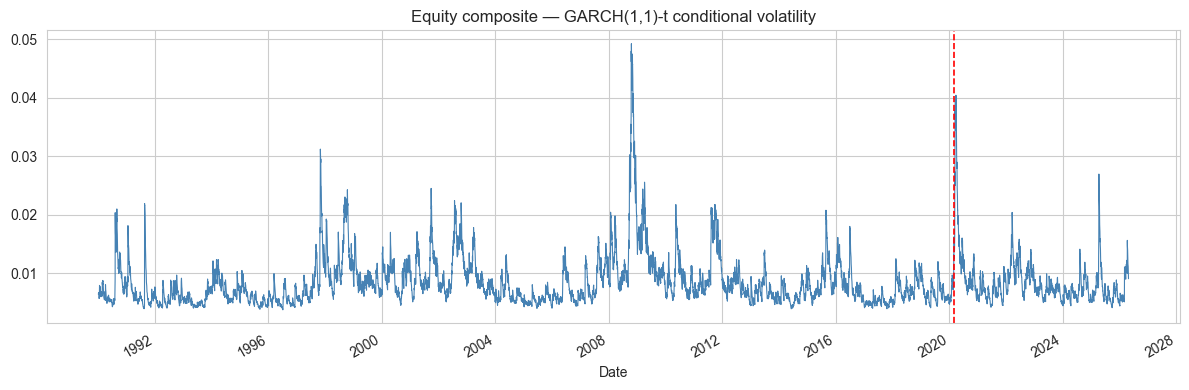

In [17]:
# fig3: full-sample conditional volatility of the composite.
CondVol = (GarchFull.conditional_volatility / GARCH_SCALE).rename('GARCH cond. vol')
fig, ax = plt.subplots(figsize=(12, 4))
CondVol.plot(ax=ax, lw=0.8, color='steelblue')
ax.axvline(COVID_BREAK_DATE, color='red', ls='--', lw=1.2)
ax.set_title('Equity composite — GARCH(1,1)-t conditional volatility')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig3_garch_conditional_vol.png', dpi=150, bbox_inches='tight')
plt.show()

### A3. Tail risk: GPD peaks-over-threshold  (Report: Table 6, Figures 7, 7b)

In [18]:
# Daily losses on the composite; fit a Generalized Pareto Distribution to exceedances over the 95th
# percentile (the principled POT threshold); xi>0 is a heavy tail.
EquityLosses = (-EquityComposite).dropna()
PreLosses    = EquityLosses[EquityLosses.index <  COVID_BREAK_DATE]
PostLosses   = EquityLosses[EquityLosses.index >= COVID_BREAK_DATE]

def fit_gpd_pot(losses, pctile=GPD_PCTILE):
    u = losses.quantile(pctile)
    exceed = losses[losses > u] - u
    xi, _, psi = genpareto.fit(exceed, floc=0)
    return xi, psi, u, len(losses), len(exceed), len(exceed) / len(losses)

def gpd_var_cvar(xi, psi, u, p_exceed, alpha=0.01):
    var  = u + (psi / xi) * ((alpha / p_exceed) ** (-xi) - 1)
    cvar = var / (1 - xi) + (psi - xi * u) / (1 - xi)
    return var, cvar

xi_pre,  psi_pre,  u_pre,  n_pre,  ne_pre,  pe_pre  = fit_gpd_pot(PreLosses)
xi_post, psi_post, u_post, n_post, ne_post, pe_post = fit_gpd_pot(PostLosses)
var_pre,  cvar_pre  = gpd_var_cvar(xi_pre,  psi_pre,  u_pre,  pe_pre)
var_post, cvar_post = gpd_var_cvar(xi_post, psi_post, u_post, pe_post)

GPDTable = pd.DataFrame([
    {'period':'Pre-COVID','n_obs':n_pre,'n_exceed':ne_pre,'threshold_u':u_pre,
     'xi_shape':xi_pre,'psi_scale':psi_pre,'VaR_99pct':var_pre,'CVaR_99pct':cvar_pre},
    {'period':'Post-COVID','n_obs':n_post,'n_exceed':ne_post,'threshold_u':u_post,
     'xi_shape':xi_post,'psi_scale':psi_post,'VaR_99pct':var_post,'CVaR_99pct':cvar_post},
]).set_index('period')
GPDTable.to_csv(RESULTS_DIR / 'table6_gpd_tail_risk.csv')
print(GPDTable)

# LR test at a COMMON threshold (properly nested). 95th = principled; 90th only as a power sensitivity.
def gpd_lr(pctile):
    u = EquityLosses.quantile(pctile)
    pe = PreLosses[PreLosses > u] - u; po = PostLosses[PostLosses > u] - u; al = EquityLosses[EquityLosses > u] - u
    xp,_,sp = genpareto.fit(pe, floc=0); xo,_,so = genpareto.fit(po, floc=0); xa,_,sa = genpareto.fit(al, floc=0)
    LR = 2*(genpareto.logpdf(pe,xp,0,sp).sum() + genpareto.logpdf(po,xo,0,so).sum() - genpareto.logpdf(al,xa,0,sa).sum())
    return LR, 1 - chi2_dist.cdf(max(LR,0), df=2), len(po)
LR95, p95, npo95 = gpd_lr(0.95)
LR90, p90, npo90 = gpd_lr(0.90)
print(f'\nLR test, 95th pct (principal): LR={LR95:.2f}, p={p95:.3f}  (post exceedances={npo95})')
print(f'LR test, 90th pct (sensitivity): LR={LR90:.2f}, p={p90:.3f}  (post exceedances={npo90})')

            n_obs  n_exceed  threshold_u  xi_shape  psi_scale  VaR_99pct  \
period                                                                     
Pre-COVID    7973       399       0.0145    0.1506     0.0071     0.0275   
Post-COVID   1626        82       0.0131    0.3527     0.0061     0.0264   

            CVaR_99pct  
period                  
Pre-COVID       0.0381  
Post-COVID      0.0429  



LR test, 95th pct (principal): LR=1.90, p=0.386  (post exceedances=68)
LR test, 90th pct (sensitivity): LR=8.45, p=0.015  (post exceedances=158)


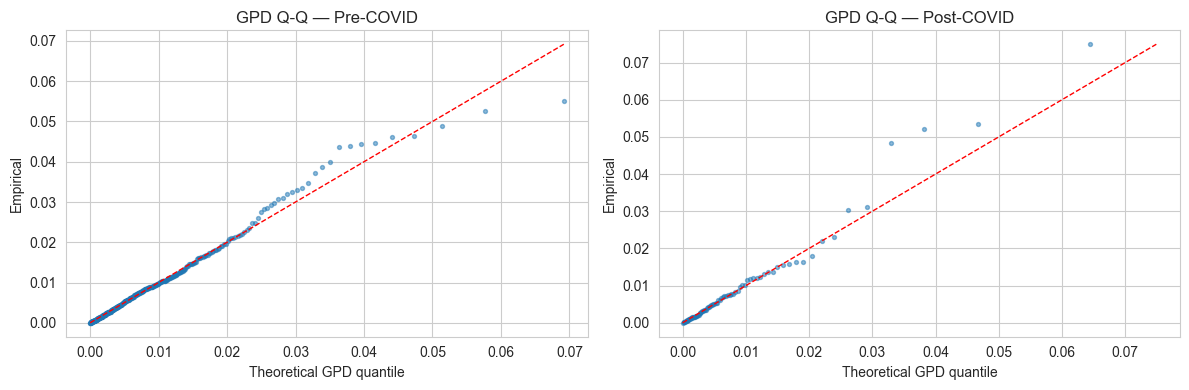

In [19]:
# fig7: GPD Q-Q plots (fit quality).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, losses, u, xi, psi, title in [
    (axes[0], PreLosses, u_pre, xi_pre, psi_pre, 'GPD Q-Q — Pre-COVID'),
    (axes[1], PostLosses, u_post, xi_post, psi_post, 'GPD Q-Q — Post-COVID')]:
    exc = np.sort(losses[losses > u].values - u); n = len(exc)
    theo = genpareto.ppf(np.arange(1, n+1)/(n+1), xi, 0, psi)
    ax.scatter(theo, exc, s=8, alpha=0.5); m = max(theo.max(), exc.max())
    ax.plot([0, m], [0, m], 'r--', lw=1); ax.set_title(title)
    ax.set_xlabel('Theoretical GPD quantile'); ax.set_ylabel('Empirical')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig7_gpd_qq.png', dpi=150, bbox_inches='tight'); plt.show()

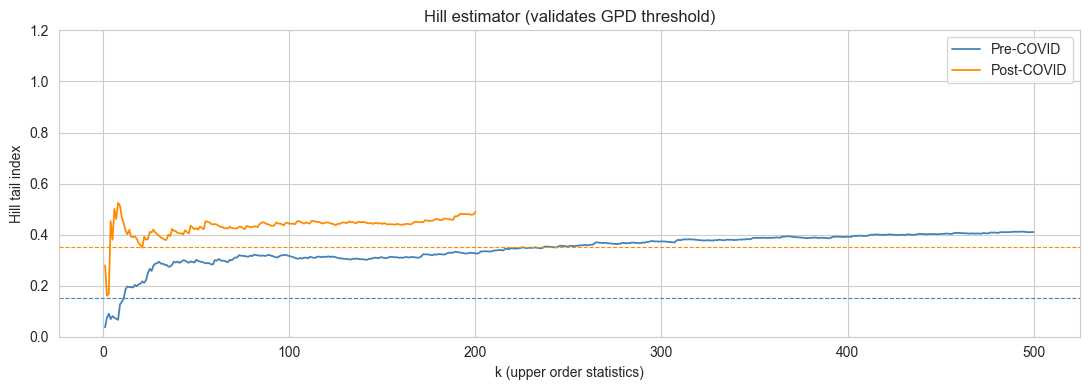

In [20]:
# fig7b: Hill estimator -- a non-parametric cross-check on the tail index.
def hill(losses, max_k):
    sl = np.sort(losses.values)[::-1]
    return np.array([np.mean(np.log(sl[:k]) - np.log(sl[k])) for k in range(1, max_k + 1)])
k_pre, k_post = min(500, len(PreLosses)//2), min(200, len(PostLosses)//2)
h_pre, h_post = hill(PreLosses, k_pre), hill(PostLosses, k_post)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(1, k_pre+1), h_pre, color='steelblue', lw=1.3, label='Pre-COVID')
ax.plot(range(1, k_post+1), h_post, color='darkorange', lw=1.3, label='Post-COVID')
ax.axhline(xi_pre, color='steelblue', ls='--', lw=0.8); ax.axhline(xi_post, color='darkorange', ls='--', lw=0.8)
ax.set_xlabel('k (upper order statistics)'); ax.set_ylabel('Hill tail index'); ax.set_ylim(0, 1.2)
ax.set_title('Hill estimator (validates GPD threshold)'); ax.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig7b_hill_estimator.png', dpi=150, bbox_inches='tight'); plt.show()

# Block B. Dependence

### B1. Average correlation and factor concentration  (Report: Table 2, Figures 2, 5, 6)

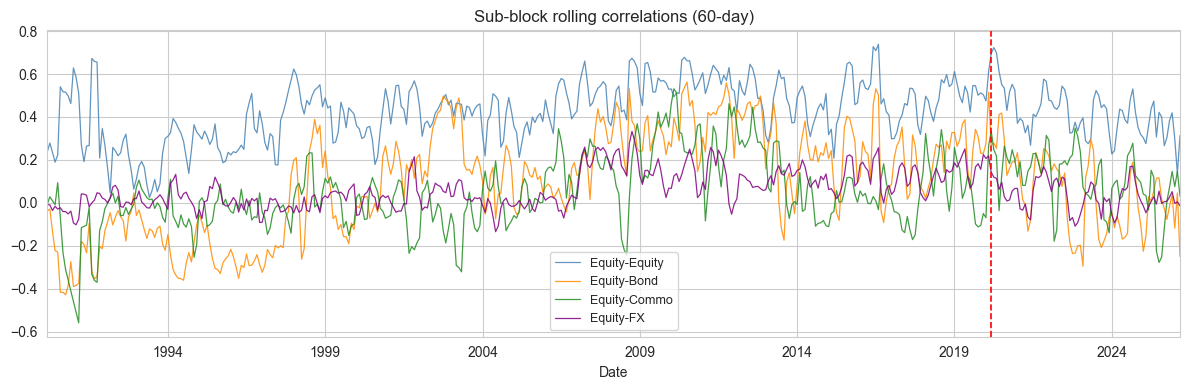

Factor concentration (block-bootstrap p-values, from table2):
          pre_mean  post_mean  p_mean_full_boot  p_var_full_boot
series                                                          
rho_bar     0.0813     0.0900            0.6387           0.1769
lambda_1    0.3351     0.3399            0.7616           0.0460
K_eff       7.6917     7.2496            0.1459           0.0190


In [21]:
# fig2: where did co-movement change? Equity vs each asset class.
fig, ax = plt.subplots(figsize=(12, 4))
for s, lbl, c in [(MonthlyRhoEquity,'Equity-Equity','steelblue'), (MonthlyRhoEqBond,'Equity-Bond','darkorange'),
                  (MonthlyRhoEqCommo,'Equity-Commo','forestgreen'), (MonthlyRhoEqFX,'Equity-FX','purple')]:
    s.plot(ax=ax, label=lbl, color=c, lw=0.9, alpha=0.85)
ax.axvline(COVID_BREAK_DATE, color='red', ls='--', lw=1.2)
ax.set_title('Sub-block rolling correlations (60-day)'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig2_subblock_correlations.png', dpi=150, bbox_inches='tight'); plt.show()
print('Factor concentration (block-bootstrap p-values, from table2):')
print(DescTable.loc[['rho_bar','lambda_1','K_eff'], ['pre_mean','post_mean','p_mean_full_boot','p_var_full_boot']])

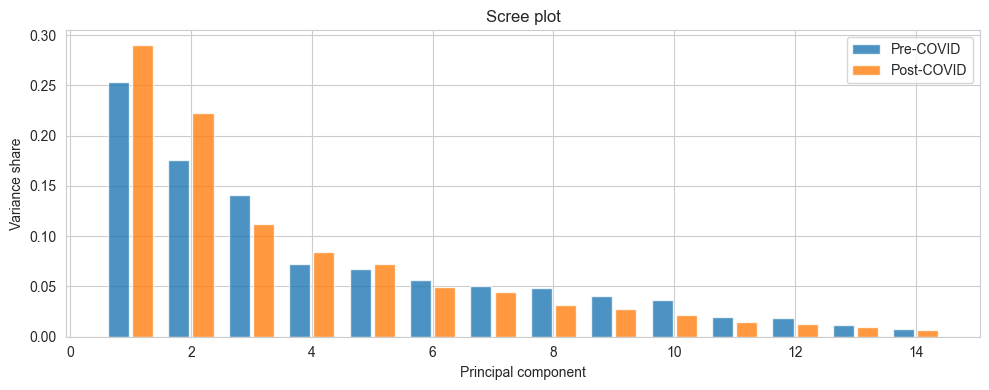

PCs for 80% of variance — pre: 7, post: 6


In [22]:
# Static PCA on each sub-sample: how many factors, and which assets drive PC1?
RetPre  = DailyReturnsAll[DailyReturnsAll.index <  COVID_BREAK_DATE].dropna()
RetPost = DailyReturnsAll[DailyReturnsAll.index >= COVID_BREAK_DATE].dropna()

def run_pca(ret_df):
    Z = (ret_df - ret_df.mean()) / ret_df.std(ddof=1)
    eigvals, eigvecs = np.linalg.eigh(np.cov(Z.values.T))
    idx = np.argsort(eigvals)[::-1]
    eigvals = np.maximum(eigvals[idx], 0)
    return eigvals, eigvecs[:, idx], eigvals / eigvals.sum()

ev_pre, evec_pre, sh_pre   = run_pca(RetPre)
ev_post, evec_post, sh_post = run_pca(RetPost)
k80_pre  = int(np.searchsorted(np.cumsum(sh_pre), 0.80)) + 1
k80_post = int(np.searchsorted(np.cumsum(sh_post), 0.80)) + 1

fig, ax = plt.subplots(figsize=(10, 4)); x = np.arange(1, 15)
ax.bar(x - 0.2, sh_pre[:14], 0.35, label='Pre-COVID', alpha=0.8)
ax.bar(x + 0.2, sh_post[:14], 0.35, label='Post-COVID', alpha=0.8)
ax.set_xlabel('Principal component'); ax.set_ylabel('Variance share'); ax.set_title('Scree plot'); ax.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig5_pca_scree.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'PCs for 80% of variance — pre: {k80_pre}, post: {k80_post}')

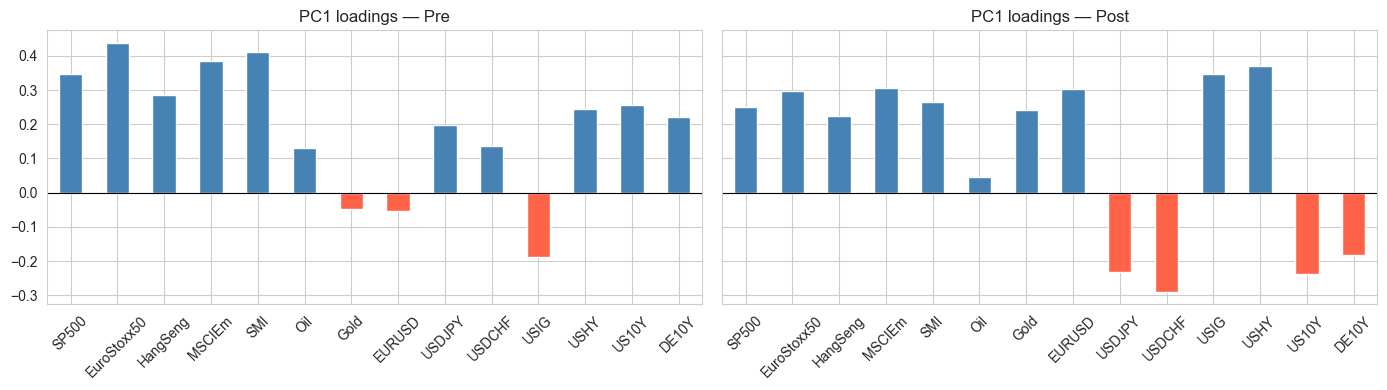

In [23]:
# fig6: PC1 loadings, pre vs post (sign-fixed so equities load positively).
LoadPre  = pd.Series(evec_pre[:, 0],  index=ALL_SERIES)
LoadPost = pd.Series(evec_post[:, 0], index=ALL_SERIES)
if LoadPre[EQUITY_SERIES].mean()  < 0: LoadPre  *= -1
if LoadPost[EQUITY_SERIES].mean() < 0: LoadPost *= -1
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, s, title in zip(axes, [LoadPre, LoadPost], ['PC1 loadings — Pre', 'PC1 loadings — Post']):
    s.plot(kind='bar', ax=ax, color=['steelblue' if v >= 0 else 'tomato' for v in s])
    ax.axhline(0, color='black', lw=0.8); ax.set_title(title); ax.tick_params(axis='x', labelrotation=45)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig6_pc1_loadings.png', dpi=150, bbox_inches='tight'); plt.show()

### B2. DCC-GARCH with EWMA cross-check  (Report: Table 7, Figure 4)

In [24]:
# Step 1: a univariate GARCH(1,1) per equity series -> standardized (heteroskedasticity-free) residuals.
DccStdResid = {}
for col in EQUITY_SERIES:
    f = arch_model(DailyLogReturns[col].dropna() * GARCH_SCALE, vol='Garch', p=1, q=1,
                   dist='Normal', mean='Constant').fit(disp='off')
    DccStdResid[col] = (f.resid / f.conditional_volatility).rename(col)
DccStdResid = pd.DataFrame(DccStdResid).dropna()
print('Standardized residuals:', DccStdResid.shape)

Standardized residuals: (9462, 5)


In [25]:
# Step 2: Engle (2002) DCC. Q_t = (1-a-b) Qbar + a z_{t-1} z_{t-1}' + b Q_{t-1}; estimate (a,b) by QMLE.
# Plain loop, two parameters -- intentionally simple and readable.
def dcc_negloglik(params, z):
    a, b = params
    if a <= 0 or b <= 0 or a + b >= 0.999:
        return 1e10
    T = len(z); Qbar = np.cov(z.T); Q = Qbar.copy(); ll = 0.0
    for t in range(T):
        if t > 0:
            zt = z[t-1][:, None]
            Q = (1 - a - b) * Qbar + a * (zt @ zt.T) + b * Q
        d = np.sqrt(np.diag(Q)); R = Q / np.outer(d, d)
        sign, logdet = np.linalg.slogdet(R)
        if sign <= 0:
            return 1e10
        zt = z[t][:, None]
        ll += -0.5 * (logdet + (zt.T @ np.linalg.solve(R, zt))[0, 0])
    return -ll

def fit_dcc(z):
    res = minimize(dcc_negloglik, [0.02, 0.95], args=(z,), method='Nelder-Mead',
                   options={'xatol': 1e-4, 'fatol': 1e-4, 'maxiter': 400})
    return res.x, -res.fun

Zfull = DccStdResid.values
Zpre  = DccStdResid[DccStdResid.index <  COVID_BREAK_DATE].values
Zpost = DccStdResid[DccStdResid.index >= COVID_BREAK_DATE].values
(a_f, b_f), ll_f = fit_dcc(Zfull)
(a_p, b_p), ll_p = fit_dcc(Zpre)
(a_o, b_o), ll_o = fit_dcc(Zpost)
LR_dcc = 2 * ((ll_p + ll_o) - ll_f)
p_dcc  = 1 - chi2_dist.cdf(max(LR_dcc, 0), df=2)
DccTable = pd.DataFrame([
    {'period':'Full','a':a_f,'b':b_f,'a+b':a_f+b_f},
    {'period':'Pre-COVID','a':a_p,'b':b_p,'a+b':a_p+b_p},
    {'period':'Post-COVID','a':a_o,'b':b_o,'a+b':a_o+b_o}]).set_index('period')
DccTable.to_csv(RESULTS_DIR / 'table7_dcc_estimates.csv')
print(DccTable)
print(f'\nLR break test (H0: same a,b pre/post): LR={LR_dcc:.2f}, p={p_dcc:.4f}  (chi2, df=2)')
print('a = reaction speed of correlations to joint shocks; b = persistence of the correlation level.')

                a      b    a+b
period                         
Full       0.0102 0.9870 0.9972
Pre-COVID  0.0098 0.9878 0.9976
Post-COVID 0.0161 0.9585 0.9746

LR break test (H0: same a,b pre/post): LR=57.06, p=0.0000  (chi2, df=2)
a = reaction speed of correlations to joint shocks; b = persistence of the correlation level.


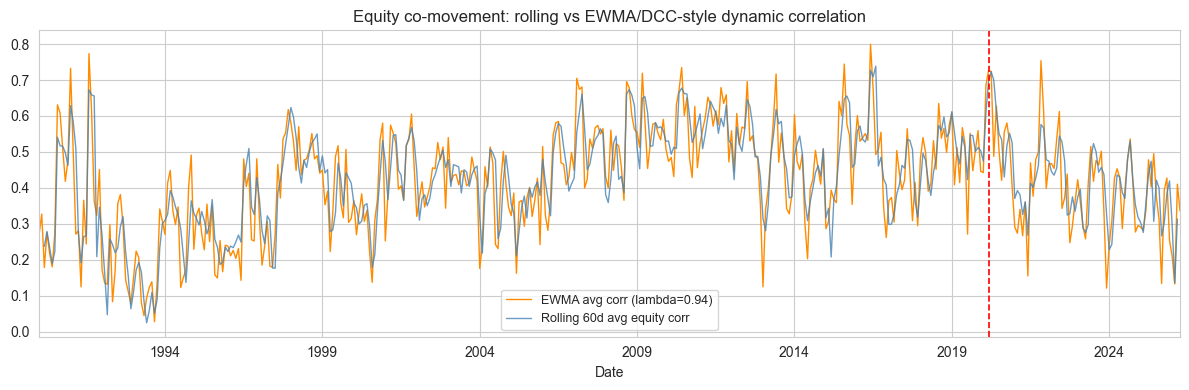

In [26]:
# EWMA is DCC with a fixed (a,b) = (1-lambda, lambda): the RiskMetrics special case. We overlay both
# to show the DCC adds genuine estimation on top of the textbook EWMA.
EWMA_LAMBDA = 0.94
Z = DccStdResid.values; T, N = Z.shape; up = np.triu_indices(N, k=1)
Q = np.cov(Z[:60].T); ewma = []
for t in range(T):
    if t > 0:
        Q = EWMA_LAMBDA * Q + (1 - EWMA_LAMBDA) * np.outer(Z[t-1], Z[t-1])
    d = np.sqrt(np.diag(Q)); R = Q / np.outer(d, d); ewma.append(R[up].mean())
EWMA_AvgCorr = pd.Series(ewma, index=DccStdResid.index)

fig, ax = plt.subplots(figsize=(12, 4))
EWMA_AvgCorr.resample('BME').last().plot(ax=ax, lw=1.0, color='darkorange', label='EWMA avg corr (lambda=0.94)')
MonthlyRhoEquity.plot(ax=ax, lw=1.0, color='steelblue', alpha=0.8, label='Rolling 60d avg equity corr')
ax.axvline(COVID_BREAK_DATE, color='red', ls='--', lw=1.2)
ax.set_title('Equity co-movement: rolling vs EWMA/DCC-style dynamic correlation'); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig4_ewma_vs_rolling.png', dpi=150, bbox_inches='tight'); plt.show()

# Block C. Dynamics and transmission

### C1. Correlation-volatility regression, ARX primary  (Report: Table 5, Appendix B)

In [27]:
FittedModels = {}
def fit_hac(name, y_col, x_cols, df=None):
    df = MonthlyDF if df is None else df
    data = pd.concat([df[y_col], sm.add_constant(df[x_cols])], axis=1).dropna()
    res = sm.OLS(data[y_col], data.drop(columns=[y_col])).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS})
    FittedModels[name] = res
    return res

# PRIMARY: ARX baseline and ARX with COVID interaction.
fit_hac('ARX_A', 'rho_bar', ['rho_bar_lag1', 'sigma_eq_lag1'])
fit_hac('ARX_F', 'rho_bar', ['rho_bar_lag1', 'sigma_eq_lag1', 'sigma_eq_lag1_x_D_post', 'D_post'])
print('--- ARX_F (PRIMARY specification) ---')
print(FittedModels['ARX_F'].summary().tables[1])
WaldARXF = FittedModels['ARX_F'].wald_test('(sigma_eq_lag1_x_D_post = 0), (D_post = 0)', scalar=True)
print(f'Joint Wald (beta2=gamma=0): stat={float(WaldARXF.statistic):.3f}, p={float(WaldARXF.pvalue):.3f}')
for nm in ['ARX_A', 'ARX_F']:
    e = FittedModels[nm].resid
    print(f'{nm} residual LB p = {acorr_ljungbox(e, lags=[6], return_df=True).lb_pvalue.iloc[-1]:.3f} (>0.05 = clean)')

--- ARX_F (PRIMARY specification) ---
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.0056      0.002      2.228      0.026       0.001       0.010
rho_bar_lag1               0.8864      0.021     42.248      0.000       0.845       0.927
sigma_eq_lag1              0.1120      0.064      1.741      0.082      -0.014       0.238
sigma_eq_lag1_x_D_post     0.0310      0.119      0.262      0.793      -0.201       0.263
D_post                    -0.0035      0.006     -0.560      0.576      -0.016       0.009
Joint Wald (beta2=gamma=0): stat=0.562, p=0.755
ARX_A residual LB p = 0.000 (>0.05 = clean)
ARX_F residual LB p = 0.000 (>0.05 = clean)


In [28]:
# Static levels models A-E, F (interaction), F* (+controls), G (placebo), H (kitchen sink).
for name, cols in {
    'A': ['sigma_eq_lag1'],
    'B': ['sigma_eq_lag1','sigma_oil_lag1','sigma_gold_lag1','sigma_em_lag1','sigma_hs_lag1'],
    'C': ['sigma_eq_lag1','CRS_lag1','TAS_lag1','Delta_US10Y_lag1'],
    'D': ['sigma_eq_lag1','sigma_usdjpy_lag1','sigma_eurusd_lag1','abs_usdchf_lag1'],
    'E': ['sigma_eq_lag1','sigma_hs_lag1','TAS_lag1','abs_usdchf_lag1'],
    'F': ['sigma_eq_lag1','sigma_eq_lag1_x_D_post','D_post'],
    'F_star': ['sigma_eq_lag1','sigma_eq_lag1_x_D_post','D_post','TAS_lag1','abs_usdchf_lag1'],
    'G': ['sigma_eq_lag1','sigma_eq_lag1_x_D_stress','D_stress'],
    'H': ['sigma_eq_lag1','sigma_eq_lag1_x_D_post','D_post','sigma_oil_lag1','sigma_gold_lag1',
          'sigma_em_lag1','sigma_hs_lag1','CRS_lag1','TAS_lag1','Delta_US10Y_lag1',
          'sigma_usdjpy_lag1','abs_usdchf_lag1'],
}.items():
    fit_hac(name, 'rho_bar', cols)

WaldF = FittedModels['F'].wald_test('(sigma_eq_lag1_x_D_post = 0), (D_post = 0)', scalar=True)
print('Model F joint Wald (beta2=gamma=0): p =', round(float(WaldF.pvalue), 3))
print('Model G placebo (stress dummy): beta2 =', round(FittedModels['G'].params['sigma_eq_lag1_x_D_stress'], 3),
      'p =', round(FittedModels['G'].pvalues['sigma_eq_lag1_x_D_stress'], 4))

Model F joint Wald (beta2=gamma=0): p = 0.546
Model G placebo (stress dummy): beta2 = -2.108 p = 0.0009


In [29]:
# Comparison table A-H + ARX.
def model_row(name):
    r = FittedModels[name]; p, pv = r.params, r.pvalues
    return {'model': name, 'adj_R2': r.rsquared_adj, 'N': int(r.nobs),
            'beta_1': p.get('sigma_eq_lag1', np.nan), 'p_beta_1': pv.get('sigma_eq_lag1', np.nan),
            'beta_2': p.get('sigma_eq_lag1_x_D_post', np.nan), 'p_beta_2': pv.get('sigma_eq_lag1_x_D_post', np.nan),
            'gamma': p.get('D_post', np.nan), 'p_gamma': pv.get('D_post', np.nan)}
CompTable = pd.DataFrame([model_row(n) for n in ['A','B','C','D','E','F','F_star','G','H','ARX_A','ARX_F']]).set_index('model')
CompTable.to_csv(RESULTS_DIR / 'table5_model_comparison.csv')
CompTable

,adj_R2,N,beta_1,p_beta_1,beta_2,p_beta_2,gamma,p_gamma
model,,,,,,,,
A,0.1711,420,1.3009,0.0000,NaN,NaN,NaN,NaN
B,0.2874,420,1.8568,0.0058,NaN,NaN,NaN,NaN
C,0.2526,420,1.4770,0.0000,NaN,NaN,NaN,NaN
D,0.2614,420,1.8296,0.0000,NaN,NaN,NaN,NaN
E,0.3582,420,2.7526,0.0000,NaN,NaN,NaN,NaN
F,0.1702,420,1.2648,0.0000,0.2159,0.4392,0.0006,0.9694
F_star,0.2787,420,1.6195,0.0000,0.1510,0.6146,-0.0251,0.1162
G,0.2019,420,3.0505,0.0000,NaN,NaN,NaN,NaN
H,0.4090,420,2.3070,0.0003,0.1488,0.7447,-0.0202,0.3543


In [30]:
# Robustness of the (null) interaction: alt breakpoints, 40-day window, first differences, GARCH-vol, alt Y.
print('Alternative breakpoints (beta2 on the interaction):')
for alt in [pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-01')]:
    d = MonthlyDF.copy()
    d['Dx'] = (d.index >= alt).astype(int); d['ix'] = d['sigma_eq_lag1'] * d['Dx']
    data = pd.concat([d['rho_bar'], sm.add_constant(d[['sigma_eq_lag1','ix','Dx']])], axis=1).dropna()
    r = sm.OLS(data['rho_bar'], data.drop(columns='rho_bar')).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS})
    print(f'  {alt.date()}: beta2={r.params["ix"]:+.3f} (p={r.pvalues["ix"]:.3f})')

# First-differenced rho_bar (robust to non-stationarity).
dfd = MonthlyDF.copy(); dfd['drho'] = dfd['rho_bar'].diff()
rd = fit_hac('F_diff', 'drho', ['sigma_eq_lag1','sigma_eq_lag1_x_D_post','D_post'], df=dfd.dropna(subset=['drho']))
print(f'First-difference F: beta2={rd.params["sigma_eq_lag1_x_D_post"]:+.3f} (p={rd.pvalues["sigma_eq_lag1_x_D_post"]:.3f})')

# Alternative dependent variables.
for y in ['lambda_1', 'K_eff']:
    r = fit_hac(f'F_{y}', y, ['sigma_eq_lag1','sigma_eq_lag1_x_D_post','D_post'])
    print(f'Y={y}: beta2={r.params["sigma_eq_lag1_x_D_post"]:+.4f} (p={r.pvalues["sigma_eq_lag1_x_D_post"]:.3f})')

Alternative breakpoints (beta2 on the interaction):
  2020-02-20: beta2=+0.191 (p=0.504)
  2020-04-01: beta2=+0.123 (p=0.665)
First-difference F: beta2=+0.007 (p=0.952)
Y=lambda_1: beta2=-0.8165 (p=0.019)
Y=K_eff: beta2=+4.9662 (p=0.320)


### C2. VAR: Granger, IRF, FEVD  (Report: Figures 9, 10, 11)

In [31]:
VarData   = MonthlyDF[['sigma_eq', 'rho_bar']].dropna()
ChosenLag = int(VAR(VarData).select_order(maxlags=12).hqic) or 1   # HQ criterion
VarRes    = VAR(VarData).fit(ChosenLag)
print(f'VAR lag (HQ) = {ChosenLag}, sample = {len(VarData)} months')
gc1 = VarRes.test_causality('rho_bar', 'sigma_eq', kind='f')
gc2 = VarRes.test_causality('sigma_eq', 'rho_bar', kind='f')
print(f'Granger sigma_eq -> rho_bar : F={gc1.test_statistic:.2f}, p={gc1.pvalue:.4f}')
print(f'Granger rho_bar  -> sigma_eq: F={gc2.test_statistic:.2f}, p={gc2.pvalue:.4f}')
print('Granger causality = predictability, not structural causality.')

VAR lag (HQ) = 4, sample = 420 months
Granger sigma_eq -> rho_bar : F=4.89, p=0.0007
Granger rho_bar  -> sigma_eq: F=4.14, p=0.0025
Granger causality = predictability, not structural causality.


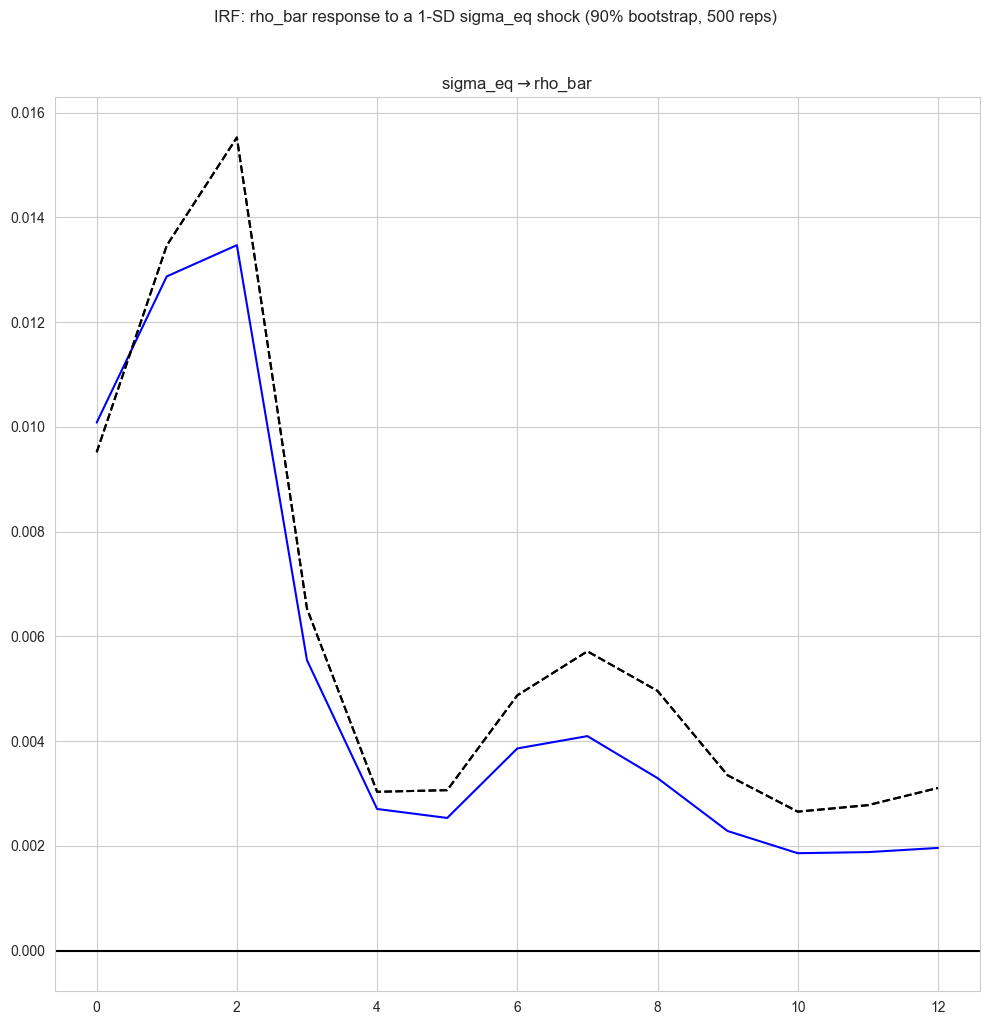

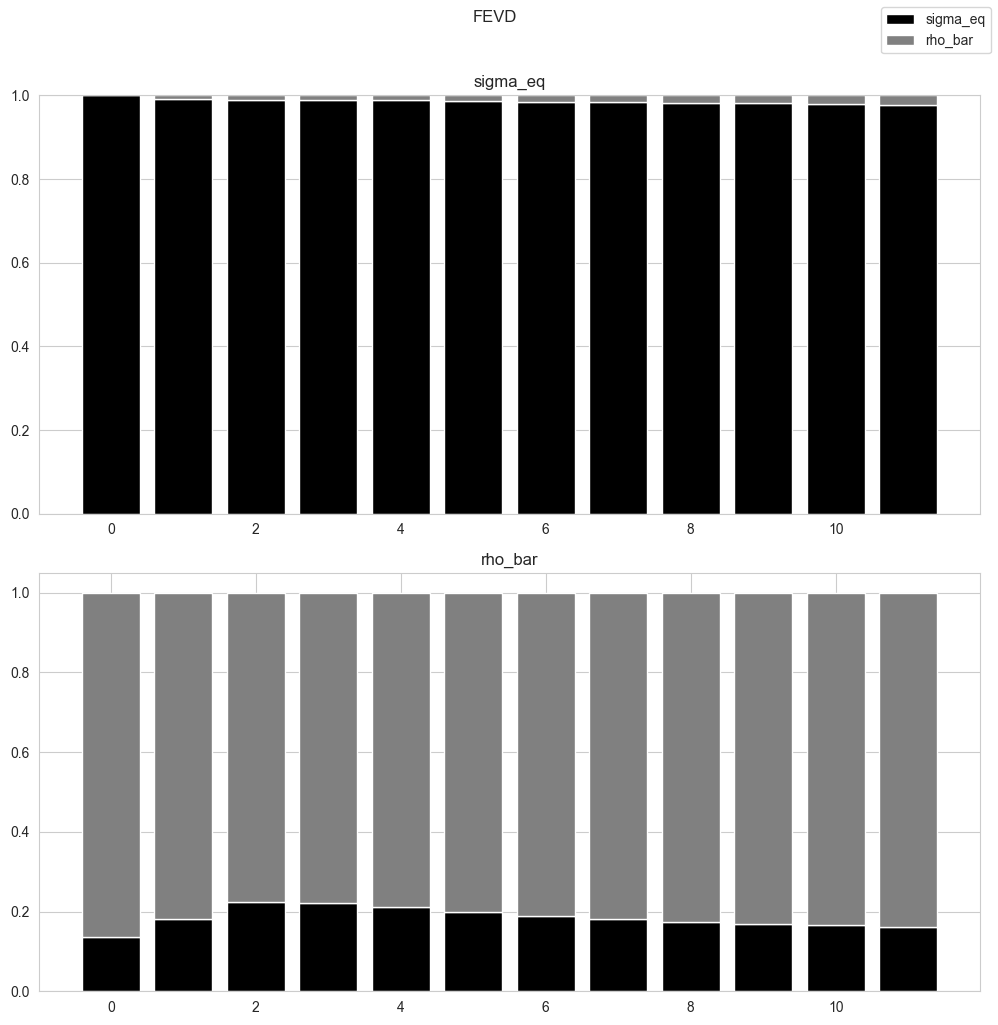

Share of rho_bar forecast variance due to sigma_eq:
  horizon  1: 0.137
  horizon  3: 0.223
  horizon  6: 0.199
  horizon 12: 0.161


In [32]:
# fig9 IRF + fig10 FEVD.
VarRes.irf(periods=12).plot(orth=True, impulse='sigma_eq', response='rho_bar', stderr_type='mc', repl=500, seed=SEED)
plt.suptitle('IRF: rho_bar response to a 1-SD sigma_eq shock (90% bootstrap, 500 reps)', y=1.02)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig9_irf.png', dpi=150, bbox_inches='tight'); plt.show()

Fevd = VarRes.fevd(periods=12); Fevd.plot()
plt.suptitle('FEVD', y=1.02); plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig10_fevd.png', dpi=150, bbox_inches='tight'); plt.show()
print('Share of rho_bar forecast variance due to sigma_eq:')
for h in [1, 3, 6, 12]:
    print(f'  horizon {h:2d}: {Fevd.decomp[1, h-1, 0]:.3f}')

Granger sigma_eq->rho_bar  pre: p=0.0062 | post: p=0.0640 (post: small sample)


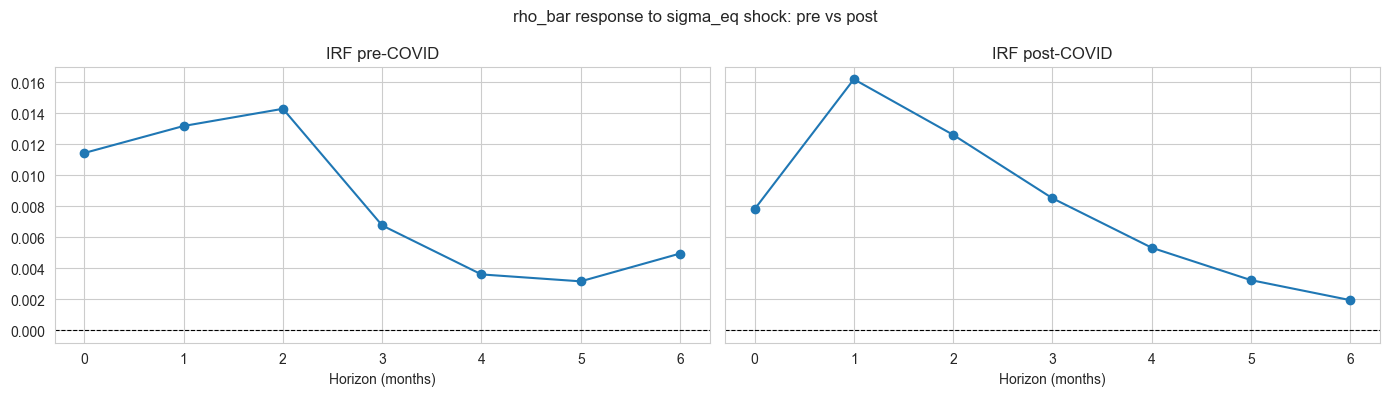

In [33]:
# fig11: pre/post IRF comparison (post on 73 obs -> noisy, flagged).
VarPre  = VAR(VarData[VarData.index <  COVID_BREAK_DATE]).fit(ChosenLag)
VarPost = VAR(VarData[VarData.index >= COVID_BREAK_DATE]).fit(min(ChosenLag, 2))
gpre = VarPre.test_causality('rho_bar', 'sigma_eq', kind='f')
gpost = VarPost.test_causality('rho_bar', 'sigma_eq', kind='f')
print(f'Granger sigma_eq->rho_bar  pre: p={gpre.pvalue:.4f} | post: p={gpost.pvalue:.4f} (post: small sample)')
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, irf_obj, title in [(axes[0], VarPre.irf(6), 'IRF pre-COVID'), (axes[1], VarPost.irf(6), 'IRF post-COVID')]:
    ax.plot(range(7), irf_obj.orth_irfs[:7, 1, 0], marker='o', lw=1.5)
    ax.axhline(0, color='black', ls='--', lw=0.8); ax.set_title(title); ax.set_xlabel('Horizon (months)')
plt.suptitle('rho_bar response to sigma_eq shock: pre vs post'); plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig11_irf_prepost.png', dpi=150, bbox_inches='tight'); plt.show()

### C3. Markov-switching regimes  (Report: Figure 8)

Low-vol regime mean=0.0294, high-vol regime mean=0.0647


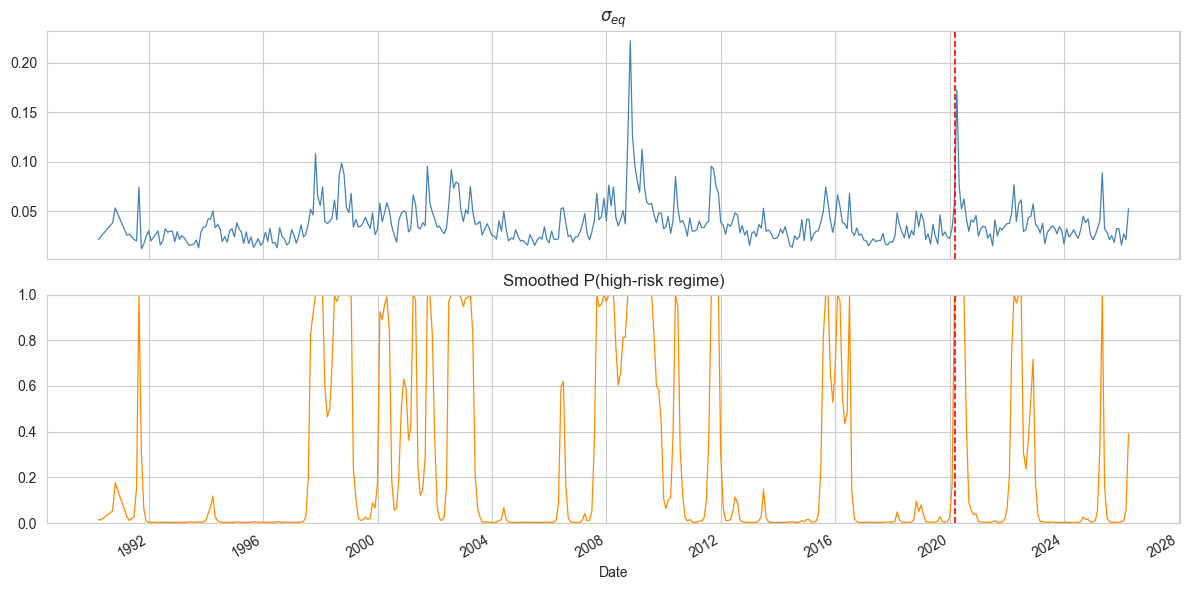

P(high-risk): full pre (1990-2020)=0.263 | recent pre (2015-2020)=0.181 | post=0.196
Difference vs recent calm: +1.4 percentage points.


In [34]:
MSSeries = MonthlyDataFrame['sigma_eq'].dropna()
MSFit = MarkovRegression(MSSeries, k_regimes=2, trend='c', switching_variance=True).fit(disp=False, search_reps=5)
sm_probs = MSFit.smoothed_marginal_probabilities
m0 = MSSeries[sm_probs.iloc[:, 0] > 0.5].mean()
m1 = MSSeries[sm_probs.iloc[:, 1] > 0.5].mean()
high = 0 if m0 > m1 else 1
HighProb = sm_probs.iloc[:, high]
print(f'Low-vol regime mean={min(m0,m1):.4f}, high-vol regime mean={max(m0,m1):.4f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
MSSeries.plot(ax=axes[0], lw=0.9, color='steelblue'); axes[0].set_title(r'$\sigma_{eq}$')
HighProb.plot(ax=axes[1], lw=0.9, color='darkorange'); axes[1].set_ylim(0, 1)
axes[1].set_title('Smoothed P(high-risk regime)')
for ax in axes: ax.axvline(COVID_BREAK_DATE, color='red', ls='--', lw=1.2)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'fig8_markov_switching.png', dpi=150, bbox_inches='tight'); plt.show()

p_full_pre = HighProb[HighProb.index < COVID_BREAK_DATE].mean()
p_recent   = HighProb[(HighProb.index >= RECENT_PRE_START) & (HighProb.index < COVID_BREAK_DATE)].mean()
p_post     = HighProb[HighProb.index >= COVID_BREAK_DATE].mean()
print(f'P(high-risk): full pre (1990-2020)={p_full_pre:.3f} | recent pre (2015-2020)={p_recent:.3f} | post={p_post:.3f}')
print(f'Difference vs recent calm: {100*(p_post - p_recent):+.1f} percentage points.')

# Synthesis  (Report: Table 8)

In [35]:
# One row per risk axis: did it change, in which direction, and how confident are we?
Synthesis = pd.DataFrame([
    {'axis':'A. Volatility level',     'changed':'No',        'evidence':'realised vol mean unchanged',
     'p':round(DescTable.loc["sigma_eq","p_mean_full_boot"],3), 'confidence':'High'},
    {'axis':'A. Volatility dynamics',  'changed':'Yes',       'evidence':'GARCH LR break; alpha up, a+b down',
     'p':round(float(p_lr_garch),3), 'confidence':'Medium (30y vs 6y; near-IGARCH pre)'},
    {'axis':'A. Tail risk',            'changed':'Probably',  'evidence':'xi, CVaR up but few exceedances',
     'p':round(float(p95),3), 'confidence':'Low (underpowered at 99% tail)'},
    {'axis':'B. Factor concentration', 'changed':'Partly (variance only)',
     'evidence':'K_eff mean change n.s. (p~.15); variance tightened, 1 fewer PC for 80%',
     'p':round(DescTable.loc["K_eff","p_var_full_boot"],3), 'confidence':'Low (block-bootstrap)'},
    {'axis':'B. Correlation dynamics', 'changed':'Yes',       'evidence':'DCC a up, b down; LR break',
     'p':round(float(p_dcc),3), 'confidence':'Medium-High'},
    {'axis':'C. Vol->corr slope',      'changed':'Not detected','evidence':'beta2 insignificant (ARX & all specs)',
     'p':round(float(WaldARXF.pvalue),3), 'confidence':'n_post=73, limited power'},
    {'axis':'C. Regime frequency',     'changed':'Weak/unclear','evidence':'benchmark-dependent sign',
     'p':np.nan, 'confidence':'Low'},
]).set_index('axis')
Synthesis.to_csv(RESULTS_DIR / 'table8_synthesis.csv')
Synthesis

,changed,evidence,p,confidence
axis,,,,
A. Volatility level,No,realised vol mean unchanged,0.9660,High
A. Volatility dynamics,Yes,"GARCH LR break; alpha up, a+b down",0.0030,Medium (30y vs 6y; near-IGARCH pre)
A. Tail risk,Probably,"xi, CVaR up but few exceedances",0.3860,Low (underpowered at 99% tail)
B. Factor concentration,Partly (variance only),K_eff mean change n.s. (p~.15); variance tight...,0.0190,Low (block-bootstrap)
B. Correlation dynamics,Yes,"DCC a up, b down; LR break",0.0000,Medium-High
C. Vol->corr slope,Not detected,beta2 insignificant (ARX & all specs),0.7550,"n_post=73, limited power"
C. Regime frequency,Weak/unclear,benchmark-dependent sign,NaN,Low
